In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, SequentialSampler, RandomSampler

from einops import rearrange
from functools import partial

import matplotlib.pyplot as plt
import numpy as np

import os
from typing import List,Tuple,Dict

import sys

# sys.path.append(os.path.abspath('../../ai4flow/acdm'))
# sys.path.append(os.path.abspath('../../ai4flow'))
sys.path.append(os.path.abspath('../ai4flow/acdm'))
sys.path.append(os.path.abspath('../ai4flow'))

from turbpred.model_diffusion import DiffusionModel
from turbpred.params import DataParams
from turbpred.model import PredictionModel
from turbpred.logger import Logger
from turbpred.params import DataParams, TrainingParams, LossParams, ModelParamsEncoder, ModelParamsDecoder, ModelParamsLatent
from turbpred.loss import PredictionLoss
from turbpred.loss_history import LossHistory
from turbpred.trainer_diffusion import TrainerDiffusion, TesterDiffusion
from dataset.airfoil_acdm import airfoilDataset
from dataset.airfoil_acdm import Transforms

device = "cuda:0" if torch.cuda.is_available() else "cpu"

/home/chunyang/miniconda3/envs/ACDM/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
self_cond = True
# model_weight_path = "/home/chunyang/projects/DDPM4Science/runs/ACDM_self_cond_airfoil_06/Model_E2400.pth"
model_weight_path = "/home/chunyang/projects/DDPM4Science/runs/ACDM_1extra_randsample_00/Model_E1600.pth"

In [3]:
p_d = DataParams(batch=32, augmentations=["normalize"], sequenceLength=[3,2], randSeqOffset=True,
            dataSize=[128,64], dimension=2, simFields=["pres"], simParams=["rey", "u_x", "u_y"], normalizeMode="incMixed")
p_t = TrainingParams(epochs=3, lr=0.001)
startFromCheckpoint = False
useGPU = True
gpuID = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = gpuID
p_l = LossParams()
p_me = None
p_md = ModelParamsDecoder(arch="direct-ddpm+Prev", diffSteps=20, diffSchedule="linear", diffCondIntegration="noisy", trainingNoise=0.0)
p_ml = None

model = PredictionModel(p_d, p_t, p_l, p_me, p_md, p_ml,
                        pretrainPath="" if not startFromCheckpoint else pretrainPath,
                        useGPU=useGPU)
model.printModelInfo()

12
in, out 18 84
Weights Trainable (All): 7006770 (7006770)      Dec: 7006770 (7006770)   
PredictionModel(
  (modelDecoder): DiffusionModel(
    (unet): Unet(
      (init_conv): Conv2d(18, 84, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
      (time_mlp): Sequential(
        (0): SinusoidalPositionEmbeddings()
        (1): Linear(in_features=128, out_features=512, bias=True)
        (2): GELU()
        (3): Linear(in_features=512, out_features=512, bias=True)
      )
      (downs): ModuleList(
        (0): ModuleList(
          (0): ConvNextBlock(
            (mlp): Sequential(
              (0): GELU()
              (1): Linear(in_features=512, out_features=84, bias=True)
            )
            (ds_conv): Conv2d(84, 84, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=84)
            (net): Sequential(
              (0): GroupNorm(1, 84, eps=1e-05, affine=True)
              (1): Conv2d(84, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (2): G

In [4]:
dataTransformationFieldIndices = [0,1,3,4]
testSet = airfoilDataset(name="V2D dataset",
                     dataDir="/home/chunyang/projects/DDPM4Science/data/airfoil_stable/test",
                     sequenceLength=[3, 2], rey=1, self_cond=self_cond)

testTransformations = Transforms()

testSet.transform = testTransformations

testSampler = SequentialSampler(testSet)
testLoader = DataLoader(testSet, sampler=testSampler, batch_size=len(testSet), drop_last=False)


Loading data from 	 /home/chunyang/projects/DDPM4Science/data/airfoil_stable/test
Loading completed. Files loaded: 	90
Dataset info detail:
	 Sequence length of each sample: 3
	 Sequence skiping samples of: 2


In [5]:
# testSet[0]

In [6]:
model = PredictionModel.load(model_weight_path, useGPU=True)
model.eval()
model.to(device)

evalOptions = {"numEvals": 1,
    "sequentialEvalRuns": {"lowRey": True, "highRey": True, "varReyIn": True},
    "samplingMode": "ddpm",
    "posteriorSampling": "random",
    "initialSampling": "random",
    "conditioningIntegration": "noisy"∆
},

if isinstance(model.modelDecoder, DiffusionModel):
    if "samplingMode" in evalOptions:
        model.modelDecoder.inferenceSamplingMode = evalOptions["samplingMode"]
    if "posteriorSampling" in evalOptions:
        model.modelDecoder.inferencePosteriorSampling = evalOptions["posteriorSampling"]
    if "initialSampling" in evalOptions:
        model.modelDecoder.inferenceInitialSampling = evalOptions["initialSampling"]
    if "conditioningIntegration" in evalOptions:
        model.modelDecoder.inferenceConditioningIntegration = evalOptions["conditioningIntegration"]

elif isinstance(model.modelDecoder, torch.nn.ModuleList):
    for module in model.modelDecoder:
        if isinstance(module, DiffusionModel):
            if "samplingMode" in evalOptions:
                module.inferenceSamplingMode = evalOptions["samplingMode"]
            if "posteriorSampling" in evalOptions:
                module.inferencePosteriorSampling = evalOptions["posteriorSampling"]
            if "initialSampling" in evalOptions:
                module.inferenceInitialSampling = evalOptions["initialSampling"]
            if "conditioningIntegration" in evalOptions:
                module.inferenceConditioningIntegration = evalOptions["conditioningIntegration"]

with torch.no_grad():
    predSamples = []
    for s, sample in enumerate(testLoader, 0):
        data = sample["data"].to(device)
        simParameters = sample["simParameters"].to(device) if type(sample["simParameters"]) is not dict else None
        prediction, _, _ = model(data, simParameters)
        # print("jijiji", data.shape, prediction.shape)
        print("prediction shape before double unsqueeze: ", prediction.shape)
        prediction = prediction.unsqueeze(0).unsqueeze(0)
        print("prediction shape after double unsqueeze: ", prediction.shape)
        predSamples += [prediction.cpu().numpy()]

    predSamples = np.concatenate(predSamples, axis=2)
    print("sampling finished")


Loading model from /home/chunyang/projects/DDPM4Science/runs/ACDM_1extra_randsample_00/Model_E1600.pth
12
in, out 18 84
prediction shape before double unsqueeze:  torch.Size([90, 3, 6, 128, 64])
prediction shape after double unsqueeze:  torch.Size([1, 1, 90, 3, 6, 128, 64])
sampling finished


In [7]:
def plot_col(axs, col_idx, tar_idx, data):
    """
    data should be of shape (3, 6, 128, 64)
    """
    for i in range(6):
        axs[i][col_idx].axis("off")
        axs[i][col_idx].imshow(data[tar_idx, i, :, :].T)

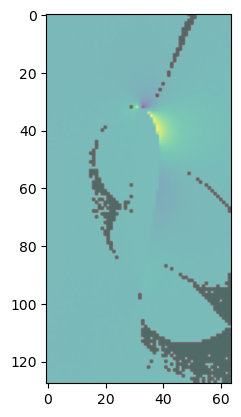

{'p': array([[ 1.04340943,  1.02489844,  1.04383429, ..., -5.46923626,
         -4.30917872, -4.67234395],
        [ 0.66777708,  0.71249767,  0.63407463, ..., -3.68970243,
         -3.63706327, -3.82244374],
        [ 0.64089959,  0.73186434,  0.48299715, ..., -4.18603296,
         -3.37735769, -3.73275647],
        ...,
        [ 2.38826288,  1.54700658,  2.55294235, ..., 17.77861146,
         24.40368711, 36.78767558],
        [ 3.52190713,  1.74936303,  4.20905209, ..., 16.82453559,
         16.75474217, 22.97951303],
        [ 1.49076902,  2.77436282,  1.60265393, ..., 23.54072955,
         18.52576745, 12.1983282 ]]),
 'ux': array([[ 0.01942326, -0.00577362,  0.05619844, ..., -0.0229925 ,
         -0.04485594,  0.0047426 ],
        [-0.02031635,  0.01455056, -0.0654896 , ..., -0.00548621,
         -0.04324109, -0.01712129],
        [ 0.0091848 , -0.04721829, -0.00862559, ..., -0.06133404,
         -0.05900792, -0.05261764],
        ...,
        [-0.08130537, -0.02924096, -0.00973

In [8]:
def find_error(input, target, mask):
    """
    input and target both have shape of (6, 128, 64).
    first 3 channel: P, Ux, Uy.
    """
    # print(type(input), type(target))
    eps = 1e-9
    input = input * mask
    target = target * mask

    error = (input - target) / (target + eps)

    fig, ax = plt.subplots()
    ax.clear()
    ax.imshow(error[0] > 10, cmap="seismic", vmin=-1, vmax=1, alpha=0.8)
    ax.imshow(input[0], alpha=0.6)
    plt.show()

    # plt.hist(x = input[1].flatten(), bins=70)
    # plt.show()
    # for i in range(3):
    #     plt.imshow(input[i, :, :])
    #     plt.show()
    #     plt.imshow(input[i, :, :] * mask)
    #     plt.show()

    # plt.hist(x = (np.abs(input - target) / (target + eps))[2].flatten())
    # plt.show()

    p_error = error[0]
    ux_error = error[1]
    uy_error = error[2]

    return {
        "p": p_error,
        "ux": ux_error,
        "uy": uy_error,
    }

idx = 23

find_error(predSamples[0][0][idx][2, :, :, :], testSet[idx]["data"][2, :, :, :].numpy(), testSet[idx]["obsMask"].numpy())

torch.Size([1, 6, 128, 64])
True


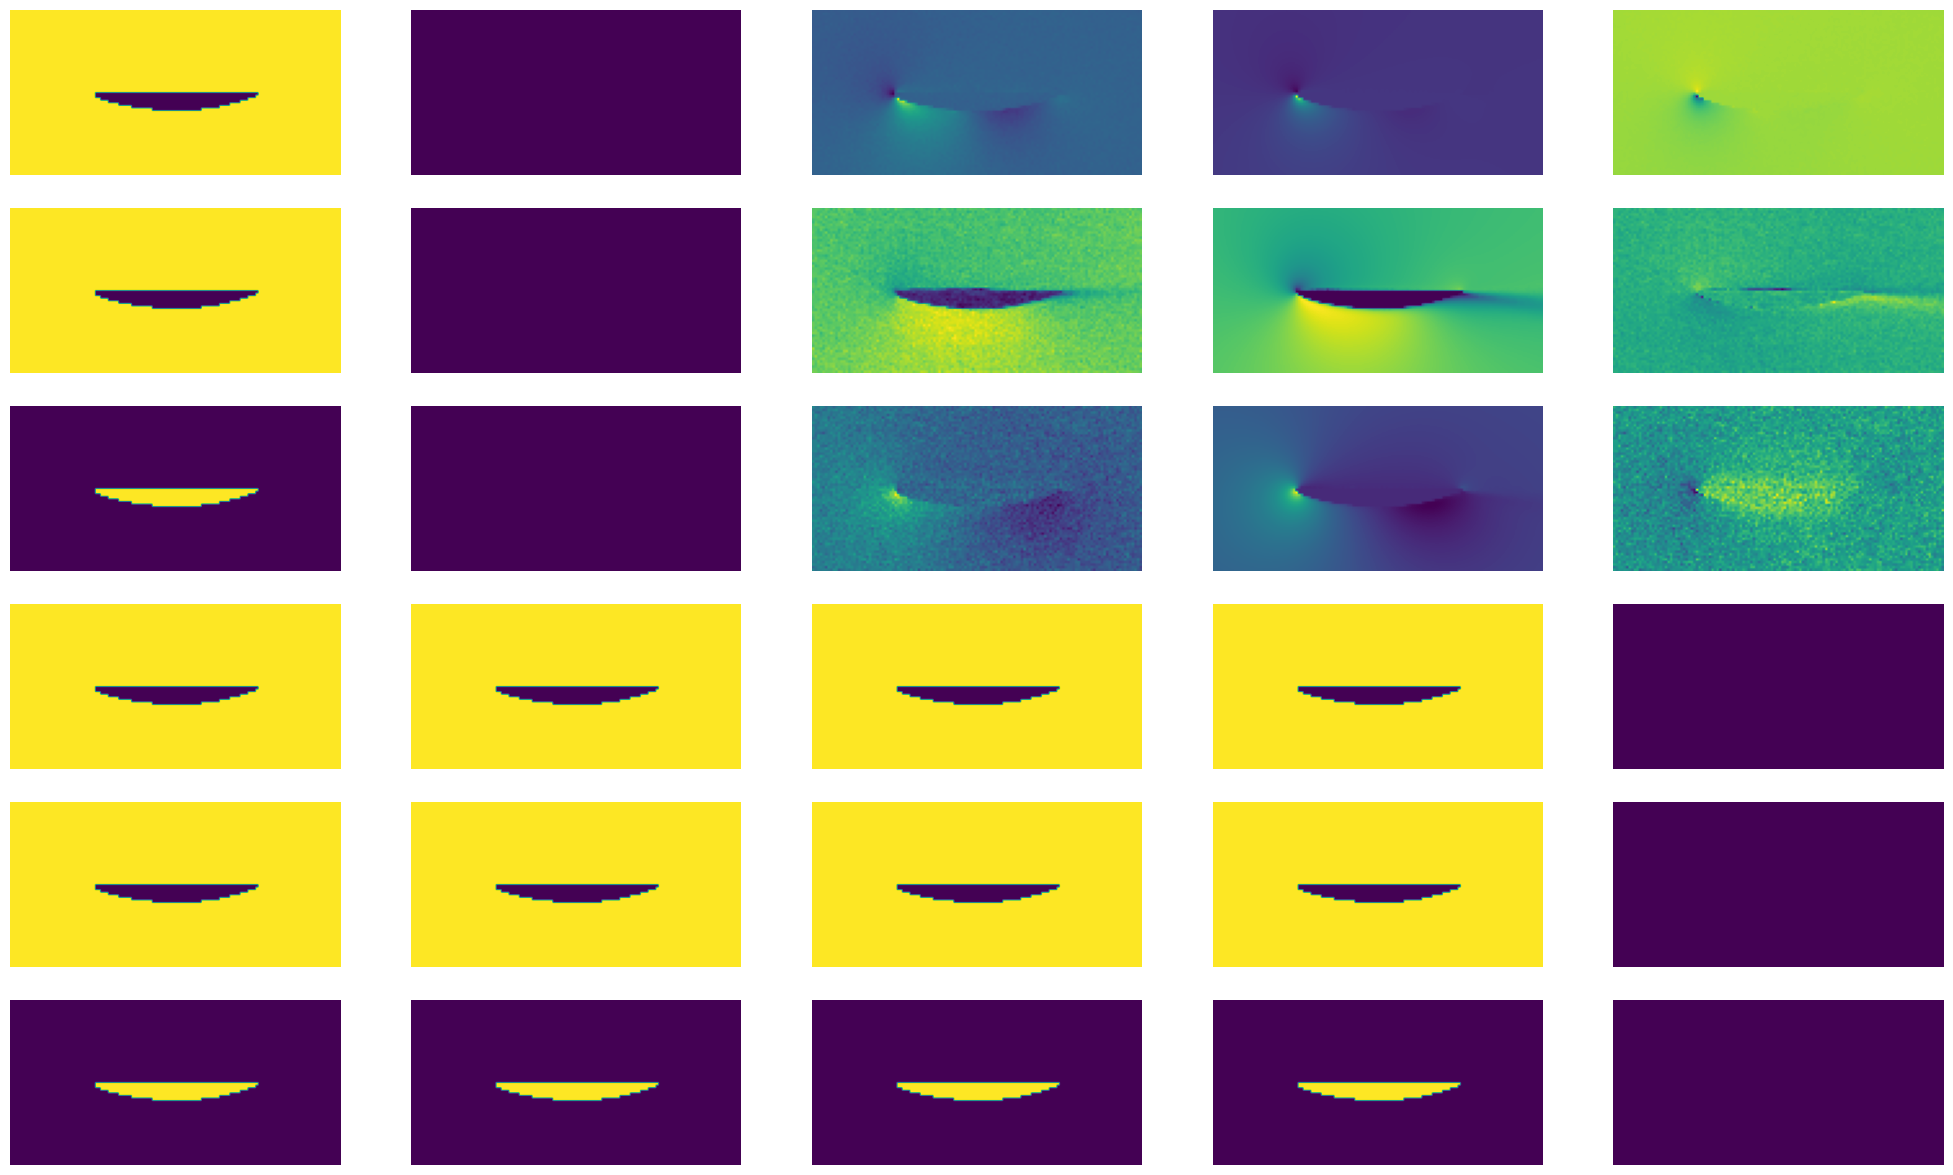

In [12]:
idx = 44

pred = torch.from_numpy(predSamples[0][0, idx, -1, :, :, :])
ground = testSet[idx]["data"][-1, :, :, :]
diff = (pred - ground).unsqueeze(dim=0)
print(diff.shape)
print(torch.allclose(pred[-3:, :, :], ground[-3:, :, :]))

fig, axs = plt.subplots(6, 5, figsize=(25, 15))

# plot the input / predicted data
for i in range(3):
    plot_col(axs, i, i, predSamples[0][0, idx, :, :, :])
# plot ground truth
plot_col(axs, 3, 2, testSet[idx]["data"])
plot_col(axs, 4, 0, diff)